[TRAIN] Inspecionando: ISIC_0001133.jpg
[VALID] Inspecionando: ISIC_0015590.jpg
[TEST] Inspecionando: ISIC_0020327.jpg


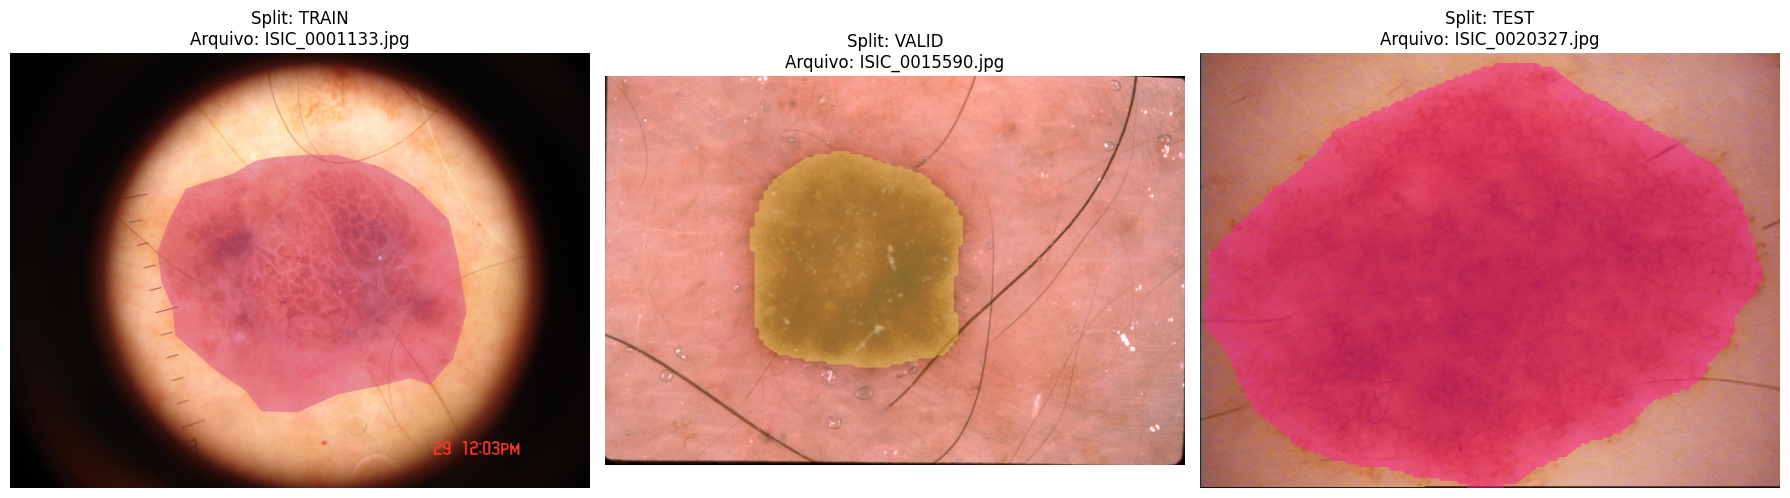

In [3]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from contextlib import redirect_stdout # <-- Importação adicionada aqui

base_dir = '/home/antoniovinicius/projects/sandbox_sam3/datasets/isic_2018_task1_coco'
splits = ['train', 'valid', 'test']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, split in enumerate(splits):
    ann_file = os.path.join(base_dir, split, '_annotations.coco.json')
    img_dir = os.path.join(base_dir, split)
    
    if not os.path.exists(ann_file):
        axes[idx].set_title(f"{split.upper()}: JSON não encontrado", color='red')
        axes[idx].axis('off')
        continue

    with open(os.devnull, 'w') as f, redirect_stdout(f):
        coco = COCO(ann_file)
        
    img_ids = coco.getImgIds()
    
    if not img_ids:
        axes[idx].set_title(f"{split.upper()}: Nenhuma imagem anotada", color='red')
        axes[idx].axis('off')
        continue

    # Escolhe uma imagem aleatória 
    random_img_id = random.choice(img_ids)
    img_data = coco.loadImgs(random_img_id)[0]
    
    just_the_name = os.path.basename(img_data['file_name'])
    print(f"[{split.upper()}] Inspecionando: {just_the_name}")

    # Carrega a imagem do disco
    img_path = os.path.join(img_dir, just_the_name)
    image = cv2.imread(img_path)
    
    if image is None:
        axes[idx].set_title(f"{split.upper()}\nErro ao carregar imagem", color='red')
        axes[idx].axis('off')
        continue
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Carrega as anotações específicas dessa imagem
    ann_ids = coco.getAnnIds(imgIds=img_data['id'])
    anns = coco.loadAnns(ann_ids)

    axes[idx].imshow(image)
    axes[idx].axis('off')
    
    plt.sca(axes[idx])
    coco.showAnns(anns) 

    axes[idx].set_title(f"Split: {split.upper()}\nArquivo: {just_the_name}")

plt.tight_layout()
plt.show()